In [1]:
import pandas as pd
import matplotlib.pyplot as plt  # O '.pyplot' é obrigatório aqui
import seaborn as sns

In [2]:
df = pd.read_csv('pokemon.csv')

In [3]:
df = df[~df['Name'].str.contains('Mega', na=False)]

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 506 entries, 0 to 552
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           506 non-null    int64 
 1   Name        506 non-null    object
 2   Type 1      506 non-null    object
 3   Type 2      245 non-null    object
 4   Total       506 non-null    int64 
 5   HP          506 non-null    int64 
 6   Attack      506 non-null    int64 
 7   Defense     506 non-null    int64 
 8   Sp. Atk     506 non-null    int64 
 9   Sp. Def     506 non-null    int64 
 10  Speed       506 non-null    int64 
 11  Generation  506 non-null    int64 
 12  Legendary   506 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 51.9+ KB


In [6]:
#quantos pokemons temos?
qtd = df['#'].count()
print(f"Temos {qtd} pokemons")

Temos 506 pokemons


In [5]:
#mostrando o top 10 pokemon com ataque mais forte

df_reduzido = df[['Name', 'Attack']]
top5 = df_reduzido.sort_values(by = 'Attack', ascending= False)[['Name', 'Attack']].head(5)
print(top5)

                      Name  Attack
424  GroudonPrimal Groudon     180
429     DeoxysAttack Forme     180
454              Rampardos     165
313                Slaking     160
543              Regigigas     160


In [6]:
#listando os pokemons com mais defesa
defesa = df.sort_values(by= 'Defense', ascending= False)[['Name', 'Defense']].head(5)
print(defesa)

         Name  Defense
230   Shuckle      230
414  Regirock      200
223   Steelix      200
98   Cloyster      180
332    Aggron      180


In [26]:
#listando os pokemons mais velozes
veloz = df.sort_values(by= 'Speed', ascending=False)[['Name', 'Type 1', 'Speed']].head()
print(veloz)

                   Name    Type 1  Speed
431   DeoxysSpeed Forme   Psychic    180
315             Ninjask       Bug    160
428  DeoxysNormal Forme   Psychic    150
429  DeoxysAttack Forme   Psychic    150
109           Electrode  Electric    140


In [8]:
#contando os pokemons type 1 = fogo
df_reduzido = df[['#', 'Name', 'Type 1']]
fogo = (df_reduzido['Type 1'] == 'Fire').sum()
print(f"O banco de dados tem {fogo} pokemon de fogo")

O banco de dados tem 31 pokemon de fogo


In [9]:
#quantos pokemons lendarios?
lendarios = (df['Legendary'] == True).sum()
print(f"No banco tem {lendarios} lendarios")

No banco tem 37 lendarios


In [10]:
#listando os pokemon tipo fogo
fogo = df_reduzido[df_reduzido['Type 1'] == 'Fire'][['Name', 'Type 1']]
print(fogo)

           Name Type 1
4    Charmander   Fire
5    Charmeleon   Fire
6     Charizard   Fire
42       Vulpix   Fire
43    Ninetales   Fire
63    Growlithe   Fire
64     Arcanine   Fire
83       Ponyta   Fire
84     Rapidash   Fire
135      Magmar   Fire
147     Flareon   Fire
158     Moltres   Fire
169   Cyndaquil   Fire
170     Quilava   Fire
171  Typhlosion   Fire
236      Slugma   Fire
237    Magcargo   Fire
259       Magby   Fire
263       Entei   Fire
270       Ho-oh   Fire
276     Torchic   Fire
277   Combusken   Fire
278    Blaziken   Fire
352       Numel   Fire
353    Camerupt   Fire
355     Torkoal   Fire
435    Chimchar   Fire
436    Monferno   Fire
437   Infernape   Fire
518   Magmortar   Fire
542     Heatran   Fire


In [11]:
#mostrando quantos são lendarios
df1 = df.groupby('Legendary')[['#']].count()
df1.sort_values('Legendary')

,#
Legendary,
False,469
True,37


In [12]:
#e quais são esses lendarios?
lista = df[df['Legendary'] == True][['Name', 'Type 1']].sort_values(by= 'Type 1', ascending= True)
print(lista)

                      Name    Type 1
549                Darkrai      Dark
425               Rayquaza    Dragon
417                 Latias    Dragon
419                 Latios    Dragon
157                 Zapdos  Electric
262                 Raikou  Electric
158                Moltres      Fire
263                  Entei      Fire
270                  Ho-oh      Fire
542                Heatran      Fire
545   GiratinaOrigin Forme     Ghost
544  GiratinaAltered Forme     Ghost
550      ShayminLand Forme     Grass
551       ShayminSky Forme     Grass
424  GroudonPrimal Groudon    Ground
423                Groudon    Ground
156               Articuno       Ice
415                 Regice       Ice
552                 Arceus    Normal
543              Regigigas    Normal
162                 Mewtwo   Psychic
269                  Lugia   Psychic
538                Mesprit   Psychic
537                   Uxie   Psychic
539                  Azelf   Psychic
430    DeoxysDefense Forme   Psychic
4

array([<Axes: ylabel='#'>], dtype=object)

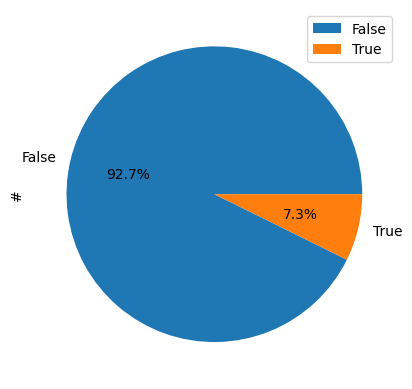

In [13]:
#porcentagem dos lendarios
df1.plot(kind='pie', subplots=True, autopct='%1.1f%%')

In [14]:
#pokemons de maior ataque da gen 2
gen2_atk = df[df['Generation'] == 2][['Name','Attack']].sort_values(by= 'Attack', ascending= False)
gen2_atk.head(5)

,Name,Attack
267,Tyranitar,134
228,Scizor,130
270,Ho-oh,130
235,Ursaring,130
231,Heracross,125


In [15]:
#pokemon com mais HP de todas as gen
gen3_hp = df[['Name','HP']].sort_values(by= 'HP', ascending= False)
gen3_hp.head(3)

,Name,HP
261,Blissey,255
121,Chansey,250
217,Wobbuffet,190


In [16]:
#listando os pokemon com mais sp. atk
sp_atk = df[['Name', 'Sp. Atk']].sort_values(by= 'Sp. Atk', ascending= False)
sp_atk.head(5)

,Name,Sp. Atk
422,KyogrePrimal Kyogre,180
429,DeoxysAttack Forme,180
162,Mewtwo,154
424,GroudonPrimal Groudon,150
425,Rayquaza,150


In [17]:
df2 = df.groupby('Sp. Atk')[['#']].count()
df2.sort_values('Sp. Atk', ascending=False).head(5)

,#
Sp. Atk,
180,2
154,1
150,6
135,3
130,6


In [18]:
poison = (df['Type 1'] == 'Poison') | (df['Type 2'] == 'Poison')
total = poison.sum()
print(f"Total de pokemons poison: {total}")

Total de pokemons poison: 50


In [19]:
#grafico de pizza de pokemons tipo flying
flying = df[(df['Type 1'] == 'Flying') | (df['Type 2'] == 'Flying')]
total = len(flying)
print(f'total flying: {total}')

total flying: 66


In [20]:
lista_flying = flying['Name']
print(lista_flying)

6             Charizard
15           Butterfree
20               Pidgey
21            Pidgeotto
22              Pidgeot
             ...       
519            Togekiss
520             Yanmega
523             Gliscor
535      RotomFan Rotom
551    ShayminSky Forme
Name: Name, Length: 66, dtype: object


In [21]:
#quantos pokemon de cada elemento?
elementos = df.groupby('Type 1')[['Name']].count()
elementos.sort_values('Type 1')

,Name
Type 1,
Bug,44
Dark,12
Dragon,13
Electric,31
Fairy,8
Fighting,15
Fire,31
Ghost,15
Grass,46


array([<Axes: ylabel='Name'>], dtype=object)

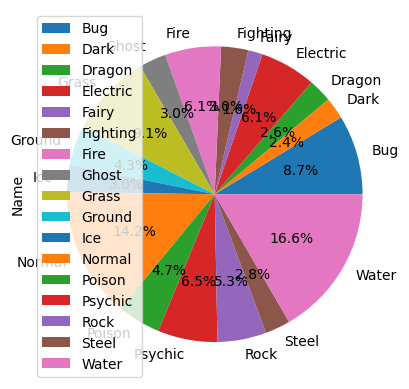

In [22]:
elementos.plot(kind = 'pie', subplots= True, autopct = '%1.1f%%')

In [23]:
#quantos lendarios do tipo 1 ou tipo 2 psiquico?


psiq = df[(df['Type 1'] == 'Psychic') | (df['Type 2'] == 'Psychic')]
cont_lend_psiq = psiq['Legendary'].sum()
lend_psiq = psiq[psiq['Legendary']]['Name']
print(f'Total de lendarios psiquicos: {cont_lend_psiq}')
print(lend_psiq)



Total de lendarios psiquicos: 12
162                 Mewtwo
269                  Lugia
417                 Latias
419                 Latios
427                Jirachi
428     DeoxysNormal Forme
429     DeoxysAttack Forme
430    DeoxysDefense Forme
431      DeoxysSpeed Forme
537                   Uxie
538                Mesprit
539                  Azelf
Name: Name, dtype: object


In [24]:
#quantos pokemon têm mais de um tipo para cada geração?

resumo_gens = df.groupby('Generation')['Type 2'].count().copy()
resumo_gens.head(10)

Generation
1    67
2    49
3    67
4    62
Name: Type 2, dtype: int64

In [25]:
#quais são os lendarios de cada geração?
lendarios = df[df['Legendary'] == True]
geracoes = lendarios.groupby('Generation')['Name'].apply(list)
for gen, nomes in geracoes.items():
    print(f"Geração {gen}: {', '.join(nomes)}\n")


Geração 1: Articuno, Zapdos, Moltres, Mewtwo

Geração 2: Raikou, Entei, Suicune, Lugia, Ho-oh

Geração 3: Regirock, Regice, Registeel, Latias, Latios, Kyogre, KyogrePrimal Kyogre, Groudon, GroudonPrimal Groudon, Rayquaza, Jirachi, DeoxysNormal Forme, DeoxysAttack Forme, DeoxysDefense Forme, DeoxysSpeed Forme

Geração 4: Uxie, Mesprit, Azelf, Dialga, Palkia, Heatran, Regigigas, GiratinaAltered Forme, GiratinaOrigin Forme, Darkrai, ShayminLand Forme, ShayminSky Forme, Arceus



In [1]:
import seaborn as sns

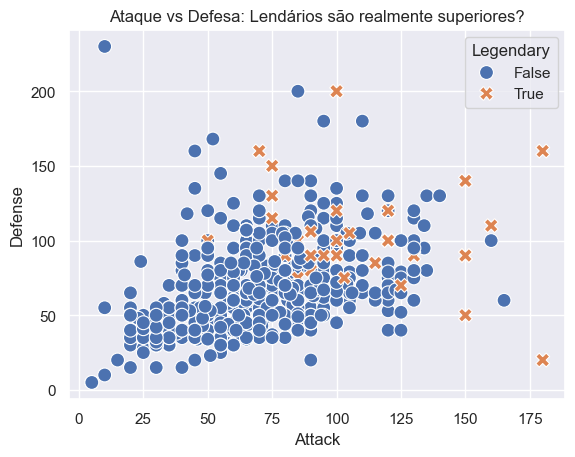

In [40]:
sns.scatterplot(data=df, x='Attack', y='Defense', hue='Legendary', style='Legendary', s=100)
plt.title('Ataque vs Defesa: Lendários são realmente superiores?')
plt.show()

In [ ]:
#: Uma matriz colorida que mostra a força da 
# relação entre todos os atributos numéricos.
# Se o quadradinho entre Attack e Speed for 
# muito escuro/claro, você prova que eles crescem juntos (ou não).

sns.heatmap(data='df', annot=True, cmap= 'Magma')

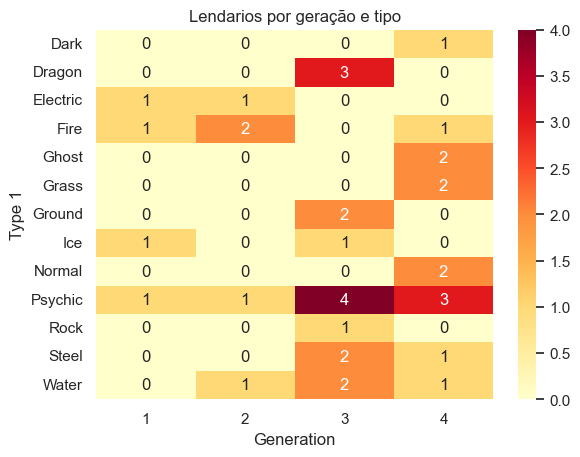

In [56]:
pivot = df[df['Legendary']==True].pivot_table(index='Type 1', columns='Generation', values='Legendary', aggfunc='count').fillna(0)
sns.heatmap(pivot, annot=True, cmap='YlOrRd')
plt.title("Lendarios por geração e tipo")
plt.show()

In [ ]:
#Qual combinação de Type 1 e Type 2 resulta na maior média de Speed

duplos = df[df['Type 2'].notna()] #filtrando os pokemons duplos
grupo = duplos.groupby(['Type 1', 'Type 2']) #agrupando os duplos
qtd = grupo['#'].count() #contando
media_speed = grupo['Speed'].mean() #media de velocidade do grupo
analise = pd.DataFrame({
    'Quantidade': qtd,
    'Velocidade_Media': media_speed
})
final = analise[analise['Quantidade'] > 1].sort_values(by='Velocidade_Media', ascending=False)
print(final.head())

                  Quantidade  Velocidade_Media
Type 1   Type 2                               
Dark     Ice               2        120.000000
Dragon   Psychic           2        110.000000
Ghost    Poison            3         95.000000
Fire     Flying            3         93.333333
Electric Flying            2         93.000000


In [87]:
#encontrar os 5 maiores canhões de vidro
df['Diferenca'] = df['Attack'] - df['Defense']
df_reduzido = df[['Name', 'Diferenca']]
df_reduzido = df_reduzido.sort_values(by= 'Diferenca', ascending=False)
print("10 maiores canhões de vidro de Pokémon até a 4ª gen")
print(df_reduzido.head(10))


10 maiores canhões de vidro de Pokémon até a 4ª gen
                   Name  Diferenca
429  DeoxysAttack Forme        160
454           Rampardos        105
428  DeoxysNormal Forme        100
453            Cranidos         85
348            Sharpedo         80
478           Honchkrow         73
392               Absol         70
147             Flareon         70
347            Carvanha         70
114           Hitmonlee         67
